# 01 · Data audit

Reads only `results/01_audit/`, written by `experiments/01_data_audit.py` and
`experiments/01_figures.py` (no API calls, no heavy compute here). Every number below
is printed from those files; the prose only says where to look.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

AUDIT = Path("../results/01_audit")
S = json.loads((AUDIT / "summary.json").read_text())
FIG = AUDIT / "figures"
pd.set_option("display.max_colwidth", 80)


def table(d, name="value"):
    return pd.Series(d, name=name).to_frame()

## 1. Do `train.csv` and `unique_m.csv` line up row by row?

Both files must have the same number of rows, the same `critical_temp` in every row, and
`number_of_elements` in `train.csv` must equal the number of nonzero element columns in
`unique_m.csv`.

In [2]:
table(S["alignment"])

,value
rows_train_csv,21263
rows_unique_m_csv,21263
same_row_count,True
critical_temp_identical_rows,21263
critical_temp_identical_all_rows,True
number_of_elements_matches_rows,21263


## 2. Overview and families

Families: cuprate (Cu and O present), iron-based (Fe with As or Se), other.

In [3]:
table({k: v for k, v in S["overview"].items() if k != "tc_K"})

,value
rows,21263
rows_tc_below_1K,1001
unique_formula_strings,15542
unique_raw_composition_vectors,15309
unique_scaled_compositions,15164
scaled_compositions_with_several_spellings,351


In [4]:
def family_row(v):
    counts = {k: x for k, x in v.items() if k != "tc_K"}
    return counts | {f"tc_{q}_K": x for q, x in v["tc_K"].items()}


pd.DataFrame({k: family_row(v) for k, v in S["families"].items()})

,cuprate,iron-based,other
rows,10532.000,1682.0000,9049.00000
materials,7510.000,1201.0000,6453.00000
rows_above_77K,3884.000,0.0000,11.00000
rows_above_100K,763.000,0.0000,5.00000
rows_above_120K,213.000,0.0000,1.00000
tc_min,0.001,0.2000,0.00021
tc_q25,31.000,12.2000,2.19000
tc_median,63.100,20.0000,4.50000
tc_q75,86.000,30.1375,8.90000
tc_max,143.000,65.0000,185.00000


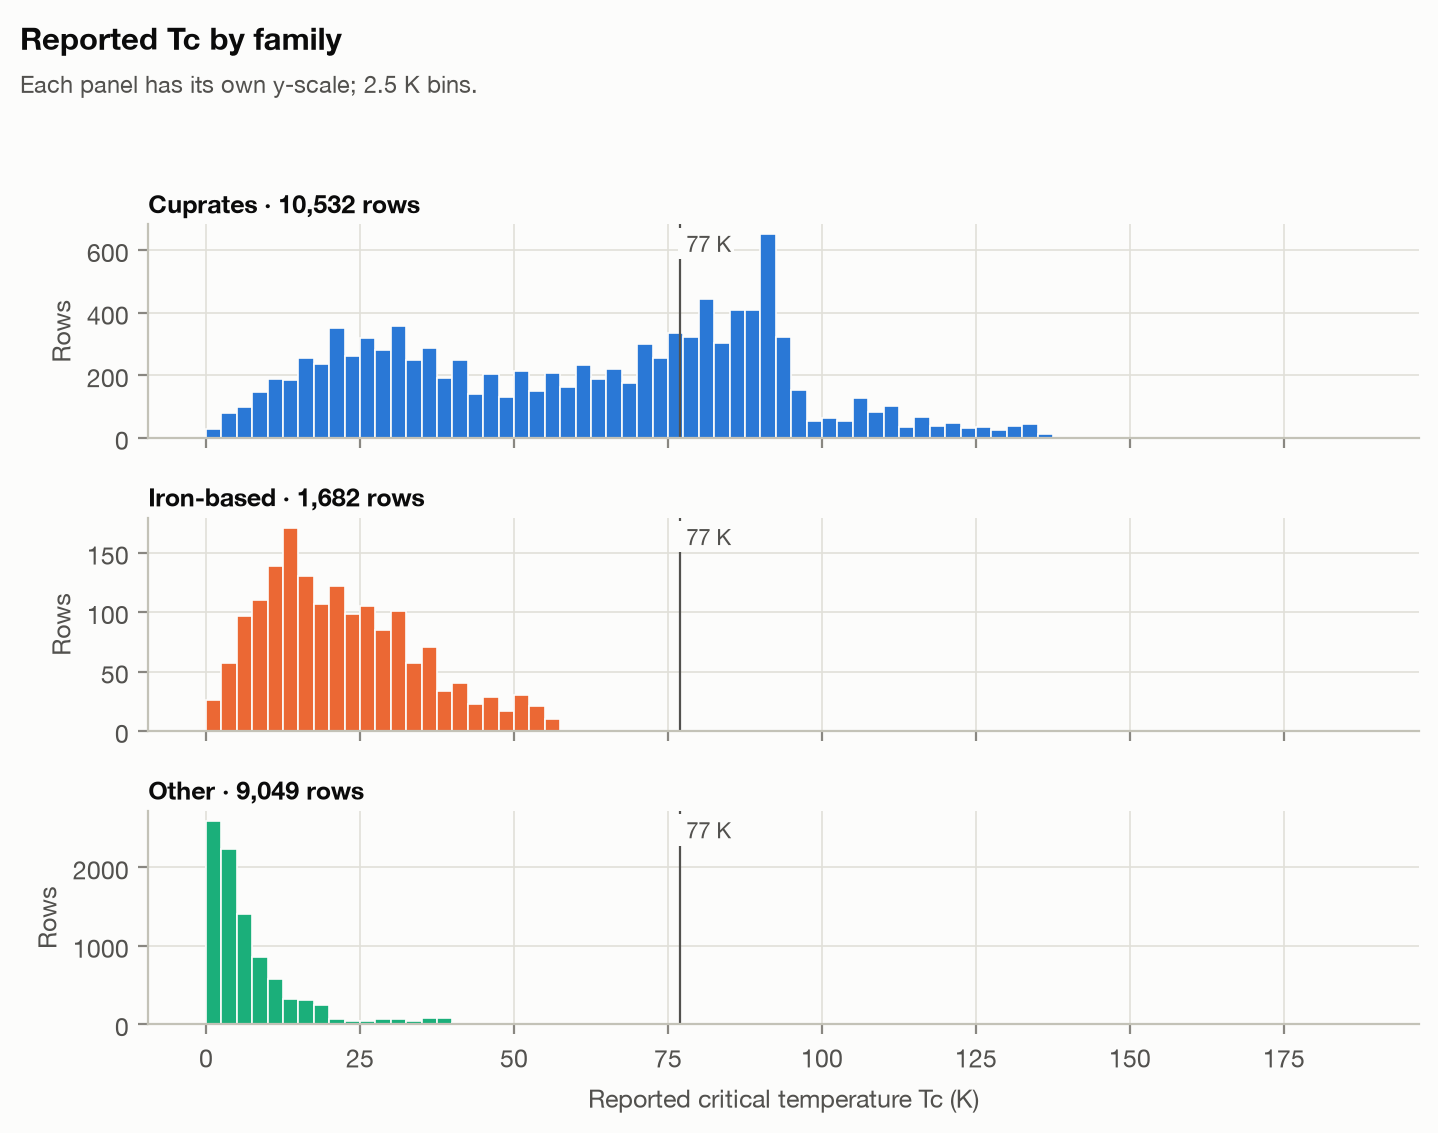

In [5]:
display(Image(FIG / "tc_by_family.png"))

## 3. Duplicates and label noise

A *material* is a scaled composition (element fractions summing to 1). The same material
often appears many times with different reported Tc. The RMSE floor is what predicting each
material's mean Tc would score on all rows: no model built on composition-derived features
can beat it.

In [6]:
table({k: v for k, v in S["duplicates"].items() if not isinstance(v, dict)})

,value
materials,15164.000000
materials_with_duplicates,2422.000000
rows_in_duplicated_materials,8521.000000
within_material_tc_sd_pooled_K,8.034077
within_material_tc_sd_median_K,1.296874
within_material_tc_range_max_K,125.000000
loo_duplicate_mean_rmse_K,9.448314
loo_duplicate_mean_mae_K,4.843453
rmse_floor_any_composition_model_K,4.302819


In [7]:
table(S["duplicates"]["materials_by_group_size"], "materials")

,materials
1,12742
2,1440
3-5,712
6-10,181
11-50,86
>50,3


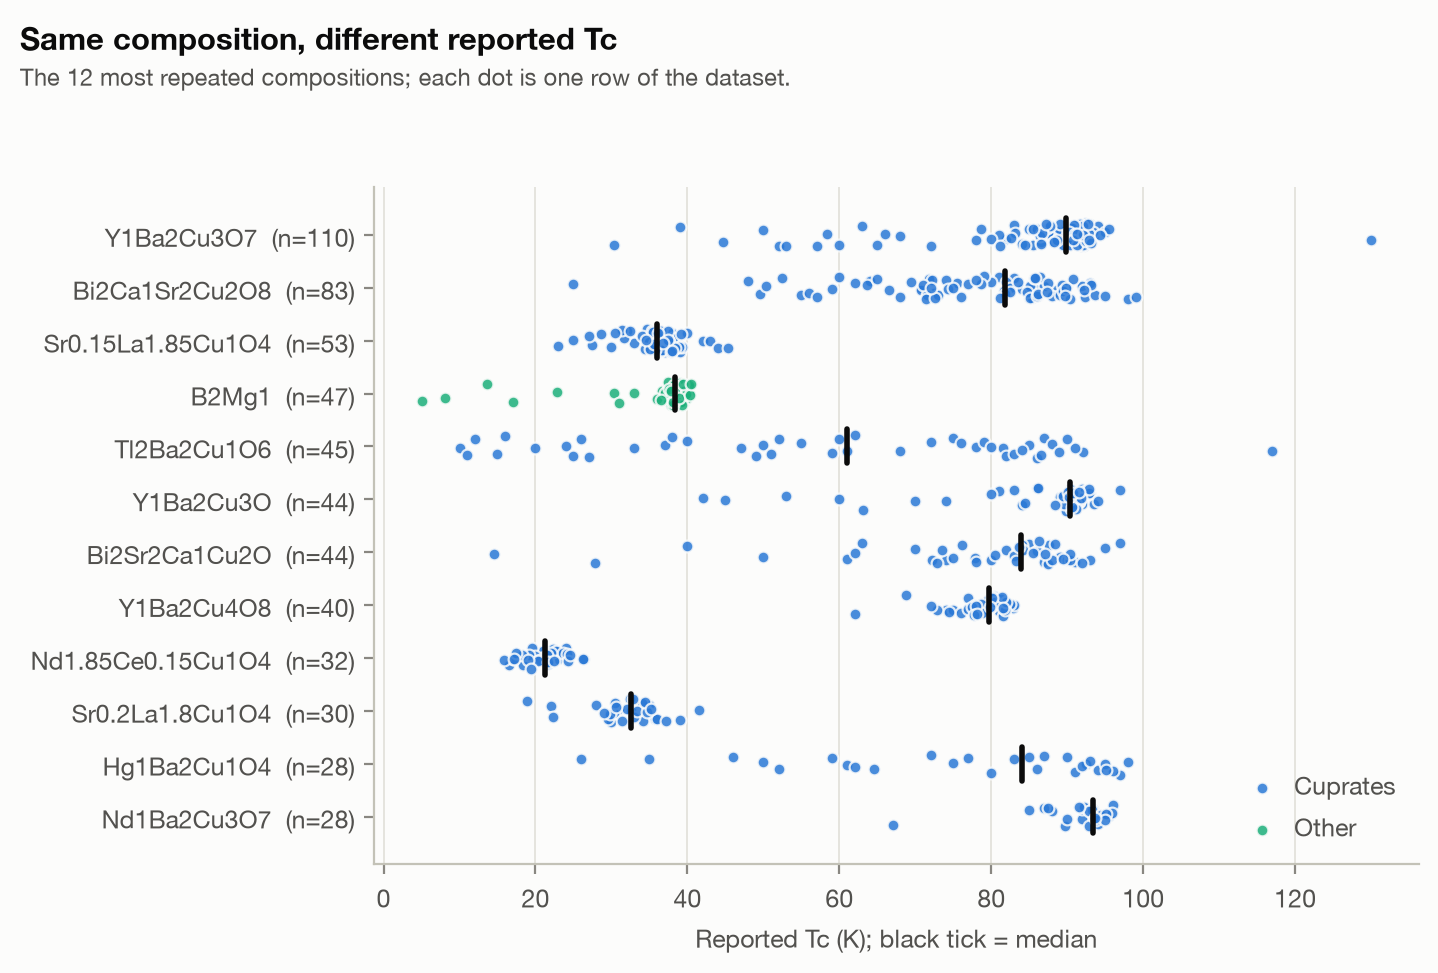

In [8]:
display(Image(FIG / "duplicate_spread.png"))

## 4. How much leakage do the splits allow?

For each test row: the L1 distance (over element fractions) to the nearest training
composition, whether an exact duplicate is in train, and whether an *oxygen-only variant*
(same composition apart from oxygen) is in train. Averaged over the 25 splits of each kind.
The 1-NN RMSE predicts each test row by its nearest training composition's median Tc.

In [9]:
table(S["leakage"]["l1_distance_example"])

,value
YBa2Cu3O7_vs_YBa2Cu3O6.9,0.007156


In [10]:
pd.DataFrame({k: S["leakage"][k] for k in ("random", "grouped")})

,random,grouped
exact_duplicate_in_train,0.347861,0.000000
oxygen_only_variant_in_train,0.216586,0.214397
nn_distance_median,0.005583,0.015496
nn_distance_below_0.01,0.566812,0.407248
nn_distance_below_0.02,0.666213,0.545870
nn_distance_below_0.05,0.801896,0.724544
nn_distance_below_0.1,0.882573,0.829074
cuprate:nn_distance_below_0.02,0.786228,0.741841
cuprate:oxygen_only_variant_in_train,0.414986,0.410812
iron-based:nn_distance_below_0.02,0.671936,0.560008


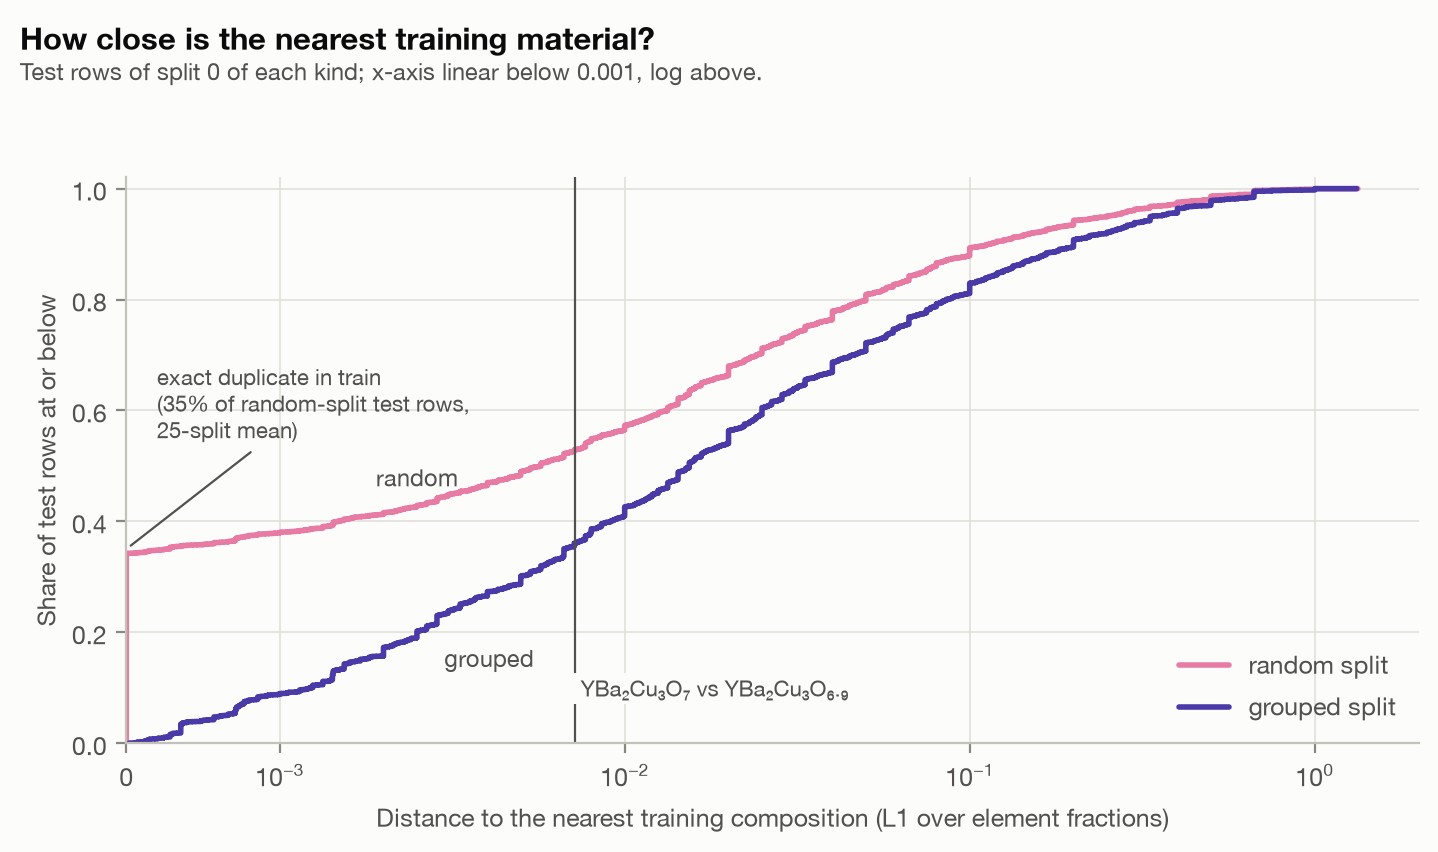

In [11]:
display(Image(FIG / "nn_distance_ecdf.png"))

## 5. Discovery pool and targets

One row per material with its median Tc. Targets for Phase 4: the top 1% of the full pool
(main scenario) and the top 1% of the non-cuprate pool (hard scenario). Random search's
expected tries to the first hit is (N + 1)/(K + 1) for K targets among N materials.

In [12]:
rows = {}
for pool in ("all", "non_cuprate", "non_cuprate_excluding_suspects"):
    p = S["discovery_pool"][pool]
    rows[pool] = {"materials": p["materials"],
                  **{f"77K_{k}": v for k, v in p["above_77K"].items()},
                  **{f"top1_{k}": v for k, v in p["top_1pct"].items()}}
pd.DataFrame(rows)

,all,non_cuprate,non_cuprate_excluding_suspects
materials,15164,7654,7637
77K_hits,2626,11,0
77K_base_rate,0.173173,0.001437,0.0
77K_random_expected_tries_to_first_hit,5.772745,637.916667,7638.0
top1_threshold_K,119.0,45.6,44.0
top1_hits,154,77,79
top1_base_rate,0.010156,0.01006,0.010344
top1_random_expected_tries_to_first_hit,97.83871,98.141026,95.475
top1_hits_by_family,"{'cuprate': 152, 'other': 2}","{'iron-based': 59, 'other': 18}","{'iron-based': 76, 'other': 3}"
top1_hit_tc_range_K,"[119.0, 143.0]","[45.6, 122.5]","[44.0, 55.6]"


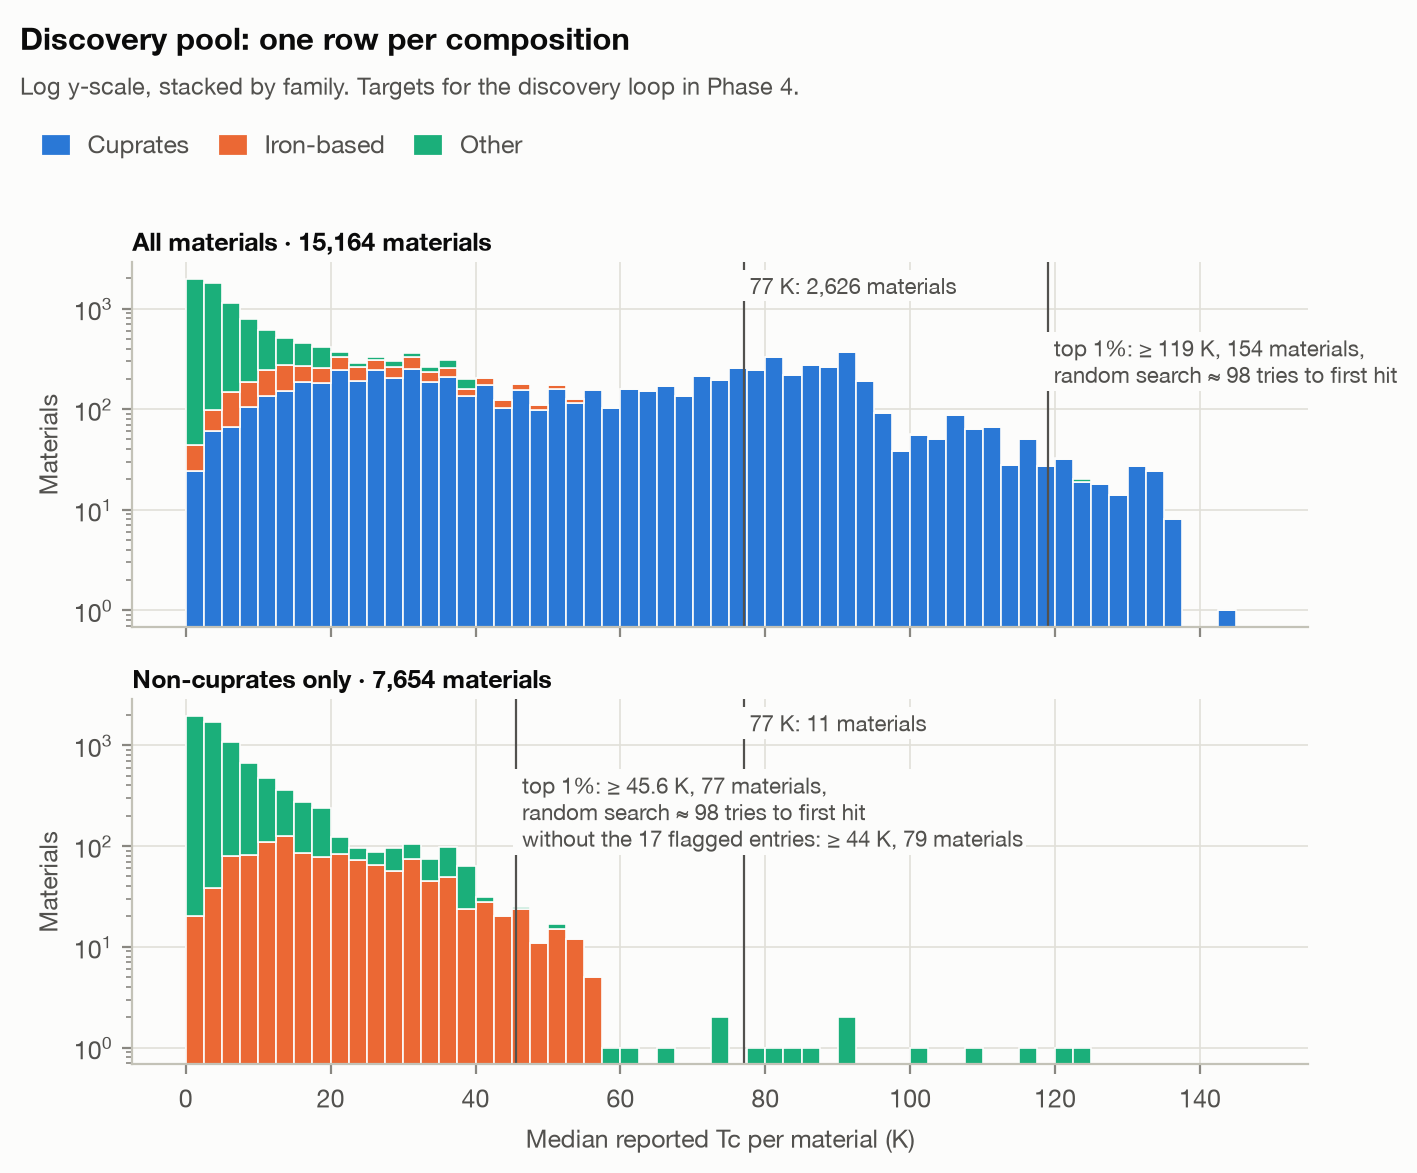

In [13]:
display(Image(FIG / "discovery_pool.png"))

### Entries flagged for review

Rule-based flags (nothing is removed): oxides with Ba or Sr but no Cu above 40 K (the look of
cuprates whose formula lost its Cu), and any non-cuprate above 77 K.

In [14]:
pd.DataFrame(S["discovery_pool"]["suspect_materials"])

,example_formula,family,tc_median,suspect
0,H2S1,other,122.5,non-cuprate above 77 K
1,H1W1O3,other,120.0,non-cuprate above 77 K
2,H1Br3C61,other,115.0,non-cuprate above 77 K
3,Bi2Sr2Ca2O,other,109.0,"cuprate-like oxide without Cu, Tc > 40 K; non-cuprate above 77 K"
4,Bi1.6Pb0.4Sr2Ca3.6O,other,102.0,"cuprate-like oxide without Cu, Tc > 40 K; non-cuprate above 77 K"
5,Na0.05W1O3,other,91.0,non-cuprate above 77 K
6,Y1Ba23O,other,90.4,"cuprate-like oxide without Cu, Tc > 40 K; non-cuprate above 77 K"
7,Hg0.8Mo0.2Sr2Y0.35Ca0.65Ca2O6,other,85.5,"cuprate-like oxide without Cu, Tc > 40 K; non-cuprate above 77 K"
8,Nd1Ba1.9La0.1O6.86,other,83.5,"cuprate-like oxide without Cu, Tc > 40 K; non-cuprate above 77 K"
9,H1Cl3C61,other,80.0,non-cuprate above 77 K


## 6. Features and oxygen

Engineered features are checked for consistency within a material. The paper's top feature,
`range_ThermalConductivity`, is shown by family. The oxygen section counts formulas that give
no oxygen amount (encoded as O = 1 in `unique_m.csv`).

In [15]:
f = S["features"]
table({k: v for k, v in f.items() if not isinstance(v, dict)})

,value
materials_with_differing_features,0
max_feature_spread_within_material,0.0
constant_features,[]
duplicated_feature_columns,[]


In [16]:
pd.DataFrame(f["range_ThermalConductivity_mode_by_family"])

,cuprate,iron-based,other
value,399.973000,78.973000,133.000000
share,0.985188,0.242568,0.035031


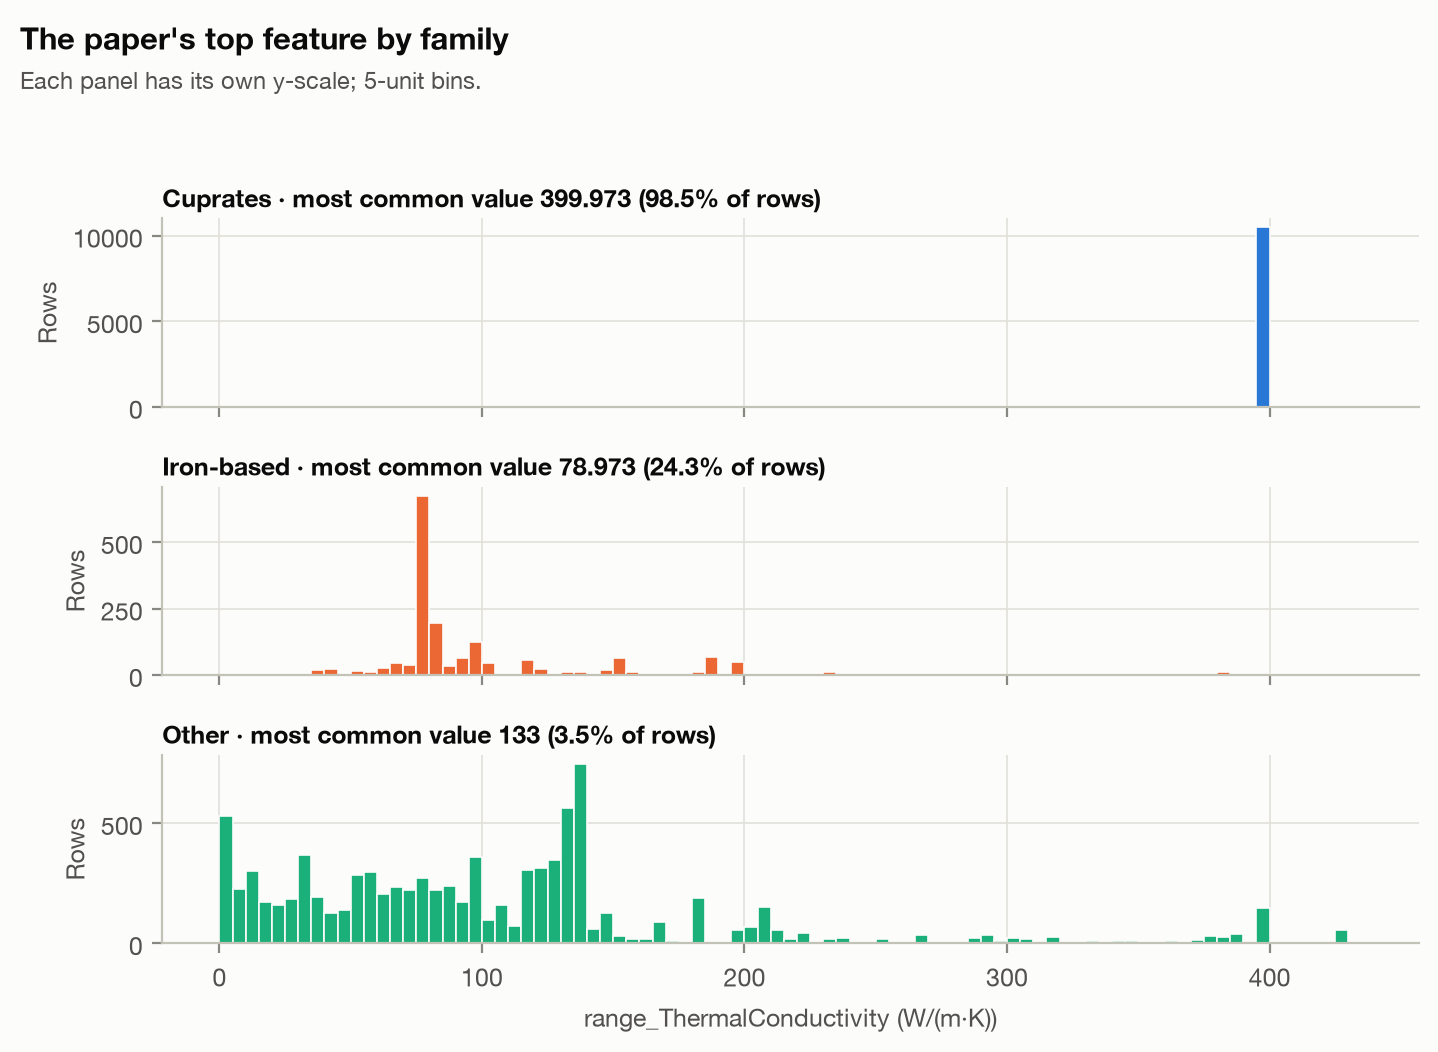

In [17]:
display(Image(FIG / "range_thermal_conductivity.png"))

In [18]:
table(S["oxygen"])

,value
rows_oxygen_amount_missing,1927
rows_oxygen_amount_missing_encoded_as,[1.0]
cuprate_rows_oxygen_amount_missing,1901
cuprate_median_tc_oxygen_missing_K,77.8
cuprate_median_tc_oxygen_given_K,59.3
cuprate_rows_integer_O,7277
cuprate_rows,10532
cuprate_rows_integer_O_share,0.690942
cuprate_materials_integer_O_share,0.637683
